In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/clothes_price_prediction_data.csv')
df.head(20)

,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113
5,Reebok,Jacket,Red,XL,Nylon,19
6,Puma,Jacket,Red,XXL,Polyester,31
7,Adidas,Dress,Red,XS,Denim,46
8,Reebok,Dress,Black,S,Wool,97
9,Adidas,Jeans,Yellow,L,Wool,80


In [3]:
colunas = {
    'Brand': 'Marca',
    'Category': 'Categoria',
    'Color': 'Cor',
    'Size': 'Tamanho',
    'Price': 'Preco'
}

df = df.rename(columns=colunas)
df.head(20)

,Marca,Categoria,Cor,Tamanho,Material,Preco
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113
5,Reebok,Jacket,Red,XL,Nylon,19
6,Puma,Jacket,Red,XXL,Polyester,31
7,Adidas,Dress,Red,XS,Denim,46
8,Reebok,Dress,Black,S,Wool,97
9,Adidas,Jeans,Yellow,L,Wool,80


In [4]:
df.describe()

,Preco
count,1000.000000
mean,106.289000
std,53.695444
min,10.000000
25%,59.750000
50%,108.000000
75%,150.000000
max,199.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Marca      1000 non-null   str  
 1   Categoria  1000 non-null   str  
 2   Cor        1000 non-null   str  
 3   Tamanho    1000 non-null   str  
 4   Material   1000 non-null   str  
 5   Preco      1000 non-null   int64
dtypes: int64(1), str(5)
memory usage: 47.0 KB


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Marca_LabelEncoder'] = le.fit_transform(df['Marca'])
df['Categoria_LabelEncoder'] = le.fit_transform(df['Categoria'])
df['Cor_LabelEncoder'] = le.fit_transform(df['Cor'])
df['Tamanho_LabelEncoder'] = le.fit_transform(df['Tamanho'])
df['Material_LabelEncoder'] = le.fit_transform(df['Material'])

df

,Marca,Categoria,Cor,Tamanho,Material,Preco,Marca_LabelEncoder,Categoria_LabelEncoder,Cor_LabelEncoder,Tamanho_LabelEncoder,Material_LabelEncoder
0,New Balance,Dress,White,XS,Nylon,182,1,0,4,4,2
1,New Balance,Jeans,Black,XS,Silk,57,1,2,0,4,4
2,Under Armour,Dress,Red,M,Wool,127,5,0,3,1,5
3,Nike,Shoes,Green,M,Cotton,77,2,3,2,1,0
4,Adidas,Sweater,White,M,Nylon,113,0,4,4,1,2
...,...,...,...,...,...,...,...,...,...,...,...
995,Puma,Jeans,Black,L,Polyester,176,3,2,0,0,3
996,Puma,Jacket,Red,XXL,Silk,110,3,1,3,5,4
997,Reebok,Sweater,Blue,XS,Denim,127,4,4,1,4,1
998,Under Armour,Sweater,Black,XXL,Denim,69,5,4,0,5,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Marca                   1000 non-null   str  
 1   Categoria               1000 non-null   str  
 2   Cor                     1000 non-null   str  
 3   Tamanho                 1000 non-null   str  
 4   Material                1000 non-null   str  
 5   Preco                   1000 non-null   int64
 6   Marca_LabelEncoder      1000 non-null   int64
 7   Categoria_LabelEncoder  1000 non-null   int64
 8   Cor_LabelEncoder        1000 non-null   int64
 9   Tamanho_LabelEncoder    1000 non-null   int64
 10  Material_LabelEncoder   1000 non-null   int64
dtypes: int64(6), str(5)
memory usage: 86.1 KB


In [8]:
y = df['Preco']

x = df.drop(columns=['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material', 'Preco'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train.shape[0]

800

In [9]:
modelo_linear = LinearRegression()

modelo_linear.fit(x_train, y_train)

previsoes_linear = modelo_linear.predict(x_test)

previsoes_linear

array([104.15646391, 113.32306379, 109.11905905, 103.27900921,
       104.69917998, 100.22122201, 105.38155848, 107.28436644,
       107.12452808, 109.24180721, 106.14223934, 113.5964202 ,
       106.38942308, 104.0022873 , 111.97500833, 105.61015975,
       106.18461362, 111.66127762, 100.79179818, 106.25204168,
       112.11238973, 104.78830619, 110.66516519, 105.10403689,
       109.26507694, 105.93095858,  97.81050715, 110.55952481,
       106.40793402, 100.46483739, 107.26131265, 105.9706456 ,
       103.15388018, 107.854349  , 104.92449715, 106.06953041,
       106.90320767, 105.47337517, 105.31293999, 108.39459053,
       103.79100654, 109.90420007, 104.65233117, 108.51614826,
       105.17615221, 112.50142617, 105.20649006, 108.93811615,
       109.06761666, 101.37441399, 100.4015713 , 103.02616051,
       102.91404883,  99.45518554, 110.94328039, 111.99351927,
       105.232947  , 110.00277233, 108.04236324, 109.79208518,
       105.4804433 , 106.2837827 , 103.65034105, 113.02

In [10]:
erro_linear = mean_absolute_error(y_test, previsoes_linear)
erro_linear

46.51755838640627

In [28]:
modelo_arvore = RandomForestRegressor(random_state=42)

modelo_arvore.fit(x_train, y_train)

previsoes_arvore = modelo_arvore.predict(x_test)

erro_arvore = mean_absolute_error(y_test, previsoes_arvore)

erro_arvore

48.583489642857145

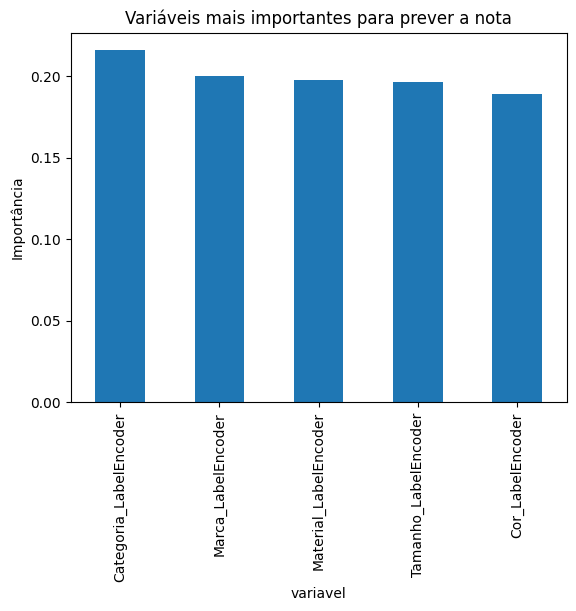

In [12]:
import pandas as pd

importances = modelo_arvore.feature_importances_

df_importancia = pd.DataFrame({
    "variavel": x_train.columns,
    "importancia": importances
}).sort_values("importancia", ascending=False)

df_importancia.head(10).plot.bar(x="variavel", y="importancia", legend=False)

plt.title("Variáveis mais importantes para prever a nota")
plt.ylabel("Importância")

plt.show()

In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df[['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material']])

encoded_df = df

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material']))

encoded_df['Preco'] = df['Preco']

encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Marca_Adidas        1000 non-null   float64
 1   Marca_New Balance   1000 non-null   float64
 2   Marca_Nike          1000 non-null   float64
 3   Marca_Puma          1000 non-null   float64
 4   Marca_Reebok        1000 non-null   float64
 5   Marca_Under Armour  1000 non-null   float64
 6   Categoria_Dress     1000 non-null   float64
 7   Categoria_Jacket    1000 non-null   float64
 8   Categoria_Jeans     1000 non-null   float64
 9   Categoria_Shoes     1000 non-null   float64
 10  Categoria_Sweater   1000 non-null   float64
 11  Categoria_T-shirt   1000 non-null   float64
 12  Cor_Black           1000 non-null   float64
 13  Cor_Blue            1000 non-null   float64
 14  Cor_Green           1000 non-null   float64
 15  Cor_Red             1000 non-null   float64
 16  Cor_White         

In [24]:
Y = encoded_df['Preco']

X = encoded_df.drop(columns=['Preco'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X

,Marca_Adidas,Marca_New Balance,Marca_Nike,Marca_Puma,Marca_Reebok,Marca_Under Armour,Categoria_Dress,Categoria_Jacket,Categoria_Jeans,Categoria_Shoes,...,Tamanho_S,Tamanho_XL,Tamanho_XS,Tamanho_XXL,Material_Cotton,Material_Denim,Material_Nylon,Material_Polyester,Material_Silk,Material_Wool
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
996,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [25]:
modelo_linear1 = LinearRegression()

modelo_linear1.fit(X_train, Y_train)

previsoes_linear1 = modelo_linear1.predict(X_test)

previsoes_linear1

array([108.61812754, 133.10712227, 113.34491094, 103.4996037 ,
       106.31937161,  92.88511033, 105.59235585, 100.04881168,
       103.68553828, 101.03566032, 106.9083136 , 115.93206916,
        95.79621969, 107.26019679, 121.11416746, 114.13019253,
       101.44430549, 127.95396782, 102.66390014, 106.2544487 ,
       109.23939312, 109.31661818, 114.39981858, 118.43153582,
       111.57316568, 110.4773336 , 109.40077234, 105.40455857,
       111.02363923,  98.33562503,  98.33370143, 106.52624031,
        99.80878531, 102.74180235, 107.83098834, 112.67791665,
       123.11281958, 106.01302511, 107.21268352,  97.4176024 ,
       110.82921679, 115.19738333,  92.58008937, 109.94673828,
       109.10816634, 111.83333191, 109.39837123, 119.44938168,
       118.15873583,  93.38373267,  97.44114424,  94.57206833,
       107.60574089, 106.6714591 , 109.65672506, 117.41922138,
       109.69873142, 100.23809557, 115.77919792, 100.97645074,
        97.60461171,  96.1864148 , 119.48012859, 116.70

In [31]:
erro_linear1 = mean_absolute_error(Y_test, previsoes_linear1)

erro_linear1

46.32198766323365

In [30]:
modelo_arvore1 = RandomForestRegressor(random_state=42)

modelo_arvore1.fit(X_train, Y_train)

previsoes_arvore1 = modelo_arvore1.predict(X_test)

erro_arvore1 = mean_absolute_error(Y_test, previsoes_arvore1)

erro_arvore1

47.551770873015876

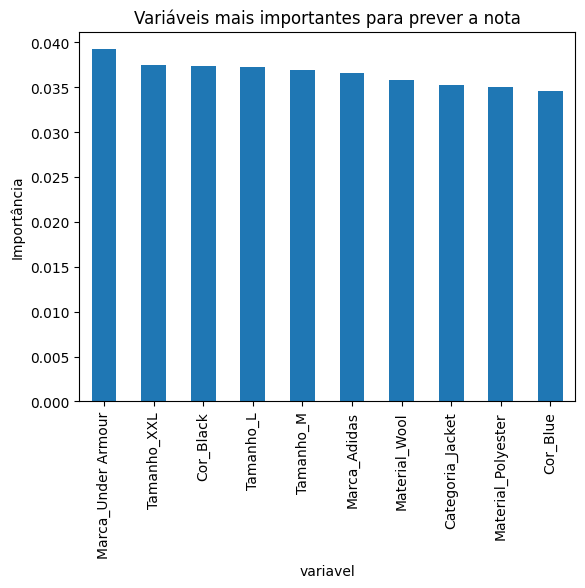

In [ ]:
import pandas as pd

df_importancia1 = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": importances1
}).sort_values("importancia", ascending=False)

df_importancia1.head(10).plot.bar(x="variavel", y="importancia", legend=False)

plt.title("Variáveis mais importantes para prever a nota")
plt.ylabel("Importância")

plt.show()

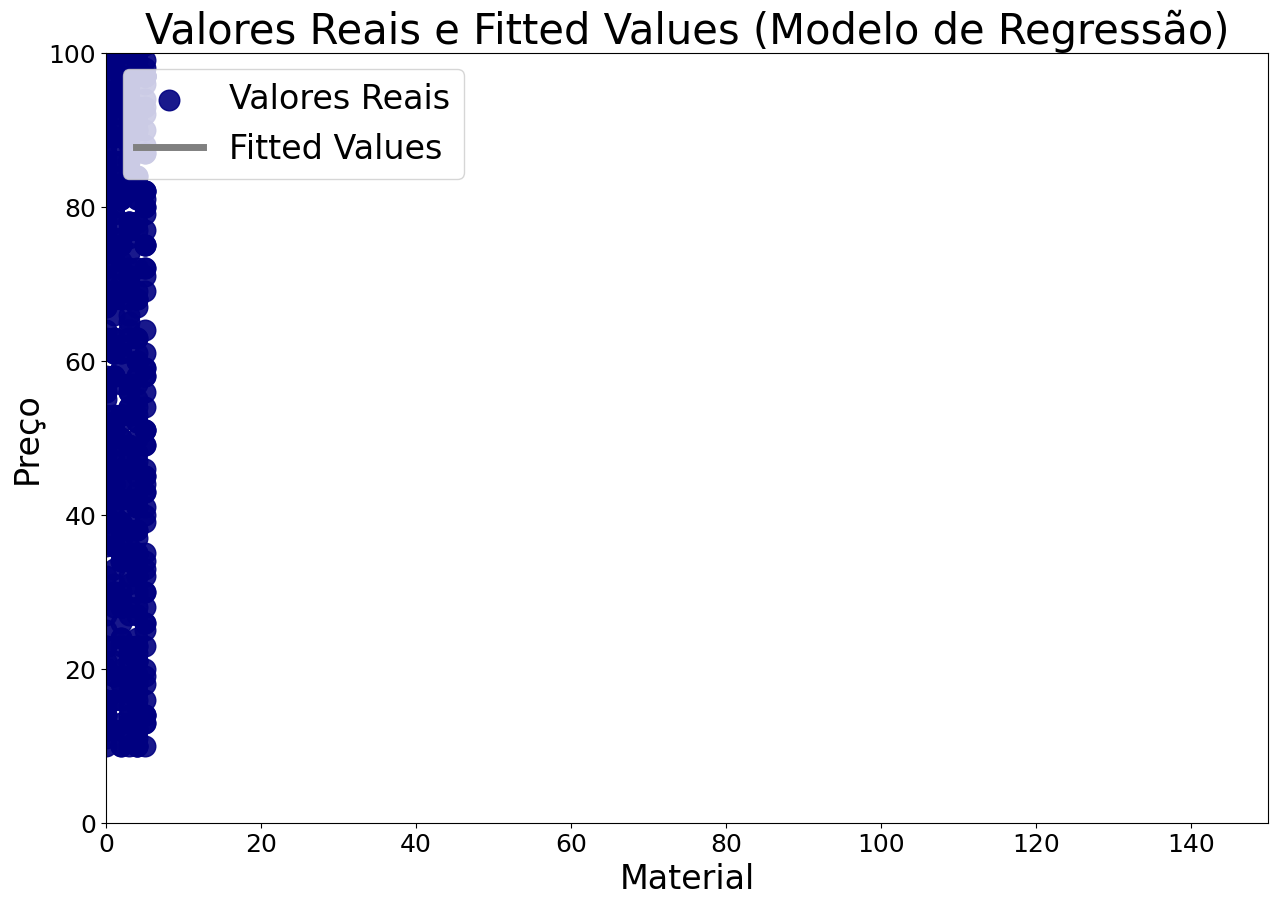

In [ ]:
plt.figure(figsize=(15,10))
sns.regplot(data=df, x='Material_LabelEncoder', y='Preco', marker='o', ci=False,
            scatter_kws={"color":'navy', 'alpha':0.9, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('Valores Reais e Fitted Values (Modelo de Regressão)', fontsize=30)
plt.xlabel('Material', fontsize=24)
plt.ylabel('Preço', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0, 150)
plt.ylim(0, 100)
plt.legend(['Valores Reais', 'Fitted Values'], fontsize=24, loc='upper left')
plt.show()